## 09. Análisis de Features — Brote de Dengue Clásico

Explora las 28 features disponibles para el problema de predicción de brote de dengue clásico (casos_clasico > P75 del canal endémico). La variable objetivo `brote` es binaria: 1 si el municipio-mes supera el umbral P75 de su canal endémico histórico (2007-2022).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = '../data/processed/features_mensual.parquet'
df = pd.read_parquet(DATA_PATH)
df['divipola'] = df['divipola'].astype(str).str.zfill(5)
print(f'Dataset mensual: {len(df):,} filas | {df["divipola"].nunique()} municipios')
print(f'Años: {df["anio"].min()} - {df["anio"].max()}')
print(f'Columnas ({len(df.columns)}): {list(df.columns)}')

Dataset mensual: 253,992 filas | 1114 municipios
Años: 2007 - 2025
Columnas (51): ['divipola', 'anio', 'mes', 'casos_clasico', 'casos_grave', 'municipio', 'departamento', 'periodo', 'temp_mean_c', 'dewpoint_mean_c', 'rain_mm_day', 'soil_water_l1_mean', 'surface_runoff_mm_day', 'total_evaporation_mm_day_ecmwf', 'wind_u_mean_ms', 'wind_v_mean_ms', 'solar_radiation_mj_m2_day', 'casos_grave_lag_1', 'casos_grave_lag_2', 'casos_grave_lag_3', 'casos_grave_lag_4', 'casos_grave_lag_6', 'casos_grave_roll3', 'casos_clasico_lag_1', 'casos_clasico_lag_2', 'casos_clasico_lag_3', 'casos_clasico_lag_4', 'casos_clasico_lag_6', 'casos_clasico_roll3', 'temp_mean_c_lag_1', 'temp_mean_c_lag_2', 'temp_mean_c_lag_3', 'rain_mm_day_lag_1', 'rain_mm_day_lag_2', 'rain_mm_day_lag_3', 'mes_sin', 'mes_cos', 'p25', 'p75', 'zona_canal', 'sir', 'es_endemico', 'brote', 'casos_objetivo', 'objetivo', 'es_inicio', 'anio_objetivo', 'mes_objetivo', 'p25_objetivo', 'p75_objetivo', 'zona_objetivo']


## 1. Variable objetivo

La variable `brote` es 1 cuando los casos de dengue clásico en un municipio-mes superan el percentil 75 (P75) de la distribución histórica de casos para ese municipio y mes calendario (referencia 2007-2022). Esta definición sigue el método del canal endémico (Bortman, 1999).

La variable `es_inicio` marca el primer mes de un episodio de brote: transición de zona normal o alerta a zona de exceso. Este es el evento de mayor valor operativo para el sistema de alerta.

In [2]:
print(f'brote = 0 (normal/alerta): {(df["brote"]==0).sum():,} ({(df["brote"]==0).mean()*100:.1f}%)')
print(f'brote = 1 (exceso/brote):  {(df["brote"]==1).sum():,} ({(df["brote"]==1).mean()*100:.1f}%)')
print(f'es_inicio = 1 (inicio episodio): {df["es_inicio"].sum():,} ({df["es_inicio"].mean()*100:.1f}%)')
print()
for nombre, mask in [('Train 2007-2023', df['anio'] <= 2023), ('Test  2024-2025', df['anio'] >= 2024)]:
    sub = df[mask]
    print(f'{nombre}: {len(sub):,} filas | brote={sub["brote"].mean()*100:.1f}% | es_inicio={sub["es_inicio"].mean()*100:.1f}%')

brote = 0 (normal/alerta): 205,027 (80.7%)
brote = 1 (exceso/brote):  48,965 (19.3%)
es_inicio = 1 (inicio episodio): 18,089 (7.2%)

Train 2007-2023: 227,256 filas | brote=16.5% | es_inicio=6.9%
Test  2024-2025: 26,736 filas | brote=43.0% | es_inicio=9.1%


## 2. Features de rezago (lags)

Lags de 1, 2, 3, 4 y 6 meses para casos clásico y casos grave, más rolling sum de 3 meses. Calculados por municipio (divipola) para evitar mezcla entre municipios distintos.

In [3]:
lag_cols = [c for c in df.columns if 'lag' in c or 'roll' in c]
print('Cobertura de features de rezago:')
for c in sorted(lag_cols):
    cov = df[c].notna().mean() * 100
    print(f'  {c:40s}: {cov:.1f}%')

Cobertura de features de rezago:
  casos_clasico_lag_1                     : 99.6%
  casos_clasico_lag_2                     : 99.1%
  casos_clasico_lag_3                     : 98.7%
  casos_clasico_lag_4                     : 98.2%
  casos_clasico_lag_6                     : 97.4%
  casos_clasico_roll3                     : 99.6%
  casos_grave_lag_1                       : 99.6%
  casos_grave_lag_2                       : 99.1%
  casos_grave_lag_3                       : 98.7%
  casos_grave_lag_4                       : 98.2%
  casos_grave_lag_6                       : 97.4%
  casos_grave_roll3                       : 99.6%
  rain_mm_day_lag_1                       : 95.9%
  rain_mm_day_lag_2                       : 95.5%
  rain_mm_day_lag_3                       : 95.1%
  temp_mean_c_lag_1                       : 95.9%


  temp_mean_c_lag_2                       : 95.5%
  temp_mean_c_lag_3                       : 95.1%


## 3. Features climáticas

Temperatura media del aire (ERA5-Land) y precipitación media diaria (CHIRPS) con sus lags de 1, 2 y 3 meses. Fuente: Google Earth Engine por municipio (DIVIPOLA).

In [4]:
clim_cols = ['temp_mean_c','temp_mean_c_lag_1','temp_mean_c_lag_2','temp_mean_c_lag_3',
             'rain_mm_day','rain_mm_day_lag_1','rain_mm_day_lag_2','rain_mm_day_lag_3']
print(df[clim_cols].describe().round(2).to_string())

       temp_mean_c  temp_mean_c_lag_1  temp_mean_c_lag_2  temp_mean_c_lag_3  rain_mm_day  rain_mm_day_lag_1  rain_mm_day_lag_2  rain_mm_day_lag_3
count    244706.00          243628.00          242550.00          241472.00    244706.00          243628.00          242550.00          241472.00
mean         20.23              20.23              20.23              20.23         5.91               5.92               5.92               5.91
std           5.09               5.09               5.09               5.09         4.31               4.31               4.31               4.31
min           7.09               7.09               7.09               7.09         0.00               0.00               0.00               0.00
25%          16.18              16.18              16.19              16.19         2.77               2.78               2.77               2.76
50%          19.86              19.87              19.87              19.87         5.05               5.07               5.

## 4. Features de canal endémico

El canal endémico clasifica el estado epidemiológico del mes actual en tres zonas:
- **0 Normal**: casos < P25 histórico
- **1 Alerta**: P25 ≤ casos ≤ P75
- **2 Exceso/Brote**: casos > P75

El SIR (razón estandarizada de incidencia) es casos_clasico / media histórica del mismo mes. La endemicidad (`es_endemico`) indica municipios con transmisión sostenida (≥10 años con casos y ≥200 casos acumulados).

In [5]:
print('zona_canal (0=normal, 1=alerta, 2=exceso):')
print(df['zona_canal'].value_counts().sort_index().to_string())
print(f'\nSIR cobertura: {df["sir"].notna().mean()*100:.1f}%')
print(df['sir'].describe().round(3).to_string())
print(f'\nMunicipios endémicos (es_endemico=1): {df[df["es_endemico"]==1]["divipola"].nunique()} '
      f'de {df["divipola"].nunique()}')

zona_canal (0=normal, 1=alerta, 2=exceso):
zona_canal
0    104432
1    100412
2     49148

SIR cobertura: 84.3%
count    214187.000
mean          1.617
std           8.181
min           0.000
25%           0.000
50%           0.000
75%           1.231
max        1280.000



Municipios endémicos (es_endemico=1): 523 de 1114


## 5. Correlación con el objetivo (brote)

Total features: 41


Top 15 features por correlación con brote:
zona_canal             0.6607
zona_objetivo          0.6333
objetivo               0.5435
sir                    0.3137
es_endemico            0.1851
temp_mean_c_lag_3      0.1849
temp_mean_c_lag_2      0.1828
temp_mean_c_lag_1      0.1808
temp_mean_c            0.1786
anio_objetivo          0.1738
casos_clasico_lag_1    0.1700
casos_objetivo         0.1690
casos_clasico_roll3    0.1632
dewpoint_mean_c        0.1624
casos_clasico_lag_2    0.1587


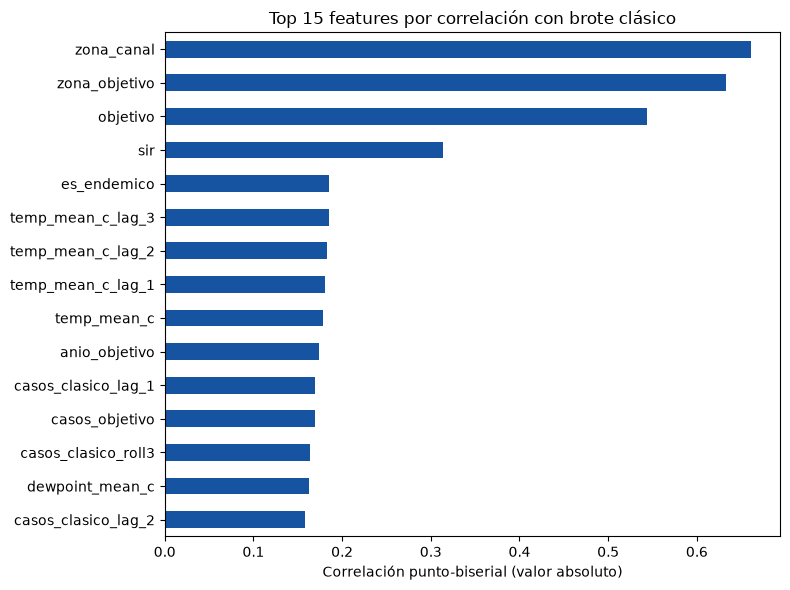

Figura guardada.


In [6]:
from scipy.stats import pointbiserialr

PROHIBIDAS = {'divipola','municipio','departamento','periodo','anio','mes',
              'casos_grave','casos_clasico','brote','es_inicio'}
feats = [c for c in df.columns if c not in PROHIBIDAS and pd.api.types.is_numeric_dtype(df[c])]
print(f'Total features: {len(feats)}')

corrs = {}
for col in feats:
    valid = df[[col, 'brote']].dropna()
    if len(valid) > 100:
        r, _ = pointbiserialr(valid['brote'], valid[col])
        corrs[col] = abs(r)

corr_s = pd.Series(corrs).sort_values(ascending=False)
print('Top 15 features por correlación con brote:')
print(corr_s.head(15).round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 6))
corr_s.head(15).sort_values().plot(kind='barh', ax=ax, color='#1654A2')
ax.set_xlabel('Correlación punto-biserial (valor absoluto)')
ax.set_title('Top 15 features por correlación con brote clásico')
plt.tight_layout()
import os; os.makedirs('../data/figures', exist_ok=True)
plt.savefig('../data/figures/09_feature_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada.')

## 6. Partición temporal

| Split | Años | Propósito |
|---|---|---|
| Entrenamiento | 2007-2023 | Ajuste de parámetros |
| Prueba | 2024-2025 | Evaluación final (no usada en entrenamiento) |

El conjunto de entrenamiento incluye un subconjunto de validación interna (2022-2023) para la selección del umbral óptimo.

In [7]:
for nombre, mask in [
    ('Entrenamiento 2007-2023', df['anio'] <= 2023),
    ('Prueba        2024-2025', df['anio'] >= 2024),
]:
    sub = df[mask]
    n_mun = sub['divipola'].nunique()
    brote_pct = sub['brote'].mean() * 100
    ini_pct   = sub['es_inicio'].mean() * 100
    print(f'{nombre}: {len(sub):,} filas | {n_mun} municipios | {brote_pct:.1f}% brote | {ini_pct:.1f}% inicios')

Entrenamiento 2007-2023: 227,256 filas | 1114 municipios | 16.5% brote | 6.9% inicios
Prueba        2024-2025: 26,736 filas | 1114 municipios | 43.0% brote | 9.1% inicios


## 7. Variables descartadas

| Grupo | Columnas | Razón |
|---|---|---|
| IDs administrativos | `divipola`, `municipio`, `departamento`, `periodo` | Sin valor predictivo |
| Conteos actuales | `casos_clasico`, `casos_grave` | Data leakage (contemporáneos al target) |
| Targets | `brote`, `es_inicio` | Son el objetivo, no features |
| Año y mes | `anio`, `mes` | Capturados por `mes_sin`/`mes_cos` y lags |